---
title: Sentinel-1 SLC Burst Selection with EOPFZARR GDAL Driver
subtitle: Directly access individual bursts from Sentinel-1 SLC products using the BURST open option
authors:
  - name: EOPF-Sample-Service Contributors
    github: EOPF-Sample-Service
    affiliations:
      - id: ESA
        institution: European Space Agency
date: 2026-03-03
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["sentinel-1", "SLC", "burst", "GDAL", "EOPFZARR", "earth observation", "remote sensing"]
tags: ["sentinel-1", "gdal", "slc"]
releaseDate: 2026-03-03
datePublished: 2026-03-03
dateModified: 2026-03-03
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

# Sentinel-1 SLC Burst Selection with EOPFZARR GDAL Driver

## Table of Contents

1. [Introduction](#Introduction)
2. [Setup](#Setup)
3. [Product Definition](#ProductDefinition)
4. [Explore Product Structure](#ExploreStructure)
5. [Select a Burst](#SelectBurst)
6. [Compare Bursts Across Subswaths](#CompareSubswaths)
7. [Visualize Burst Amplitude](#VisualizeBurst)
8. [Compare Polarizations](#ComparePolarizations)
9. [Summary](#Summary)

(Introduction)=
## Introduction

Sentinel-1 SLC (Single Look Complex) products in IW (Interferometric Wide) mode contain many bursts spread across multiple subswaths and polarizations. A typical IW dual-pol product has **54 bursts** (9 bursts × 3 subswaths × 2 polarizations), producing over 1000 subdatasets.

The EOPFZARR GDAL driver provides a `BURST` open option with a **friendly naming scheme** to directly select a specific burst without navigating the full subdataset list.

:::{hint} Overview

**Questions**
- How do I access individual bursts from a Sentinel-1 SLC product?
- What is the burst naming convention?
- How do I visualize and compare SLC burst data?

**Objectives**
- Use the `BURST` open option to select a specific burst directly by name.
- Understand the `{subswath}_{polarization}_{index}` naming scheme (e.g. `IW1_VV_001`).
- Compare bursts across subswaths and polarizations.
- Compute and visualize SLC amplitude from complex data.
:::

(Setup)=
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

gdal.UseExceptions()

print(f"GDAL version: {gdal.__version__}")
drv = gdal.GetDriverByName('EOPFZARR')
print(f"EOPFZARR driver: {'registered' if drv else 'NOT FOUND — install the EOPFZARR plugin'}")

GDAL version: 3.12.0dev-209c099c56
EOPFZARR driver: registered


/home/yadagale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


(ProductDefinition)=
## Product Definition

We use a Sentinel-1C IW SLC product with dual VV/VH polarization, stored in EOPF Zarr format on the EODC notebook-data stable bucket.

In [2]:
SLC_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "notebook-data/tutorial_data/cpm_v262/"
    "S1C_IW_SLC__1SDV_20251016T165627_20251016T165654_004590_00913B_30C4.zarr"
)

print("Product: S1C_IW_SLC__1SDV_20251016T165627")
print("Mode:    IW SLC, Dual VV/VH polarization")

Product: S1C_IW_SLC__1SDV_20251016T165627
Mode:    IW SLC, Dual VV/VH polarization


(ExploreStructure)=
## Explore Product Structure

Without the `BURST` option, opening an SLC product exposes all subdatasets — over 1000 paths for a typical dual-pol IW product. The `BURST` option simplifies this.

In [3]:
ds = gdal.Open(f"EOPFZARR:'{SLC_URL}'")

subdatasets = ds.GetMetadata("SUBDATASETS")
all_names = sorted([v for k, v in subdatasets.items() if "_NAME" in k])
slc_names = [s for s in all_names if "measurements/slc" in s]

print(f"Total subdatasets:           {len(all_names)}")
print(f"SLC measurement subdatasets: {len(slc_names)}")
print(f"\nFirst 5 SLC subdatasets:")
for s in slc_names[:5]:
    print(f"  {s.split('/')[-3]}/{s.split('/')[-2]}/{s.split('/')[-1]}")
print(f"  ... and {len(slc_names) - 5} more")

ds = None

Total subdatasets:           1296
SLC measurement subdatasets: 54

First 5 SLC subdatasets:
  S01SIWSLC_20251016T165627_0027_C026_30C4_00913B_VH_IW1_92598/measurements/slc
  S01SIWSLC_20251016T165627_0027_C026_30C4_00913B_VH_IW1_92599/measurements/slc
  S01SIWSLC_20251016T165627_0027_C026_30C4_00913B_VH_IW1_92600/measurements/slc
  S01SIWSLC_20251016T165627_0027_C026_30C4_00913B_VH_IW1_92601/measurements/slc
  S01SIWSLC_20251016T165627_0027_C026_30C4_00913B_VH_IW1_92602/measurements/slc
  ... and 49 more


(SelectBurst)=
## Select a Burst

Use the `BURST` open option to select a burst directly by its friendly name: `{subswath}_{polarization}_{index}`.

In [4]:
ds_burst = gdal.OpenEx(
    f"EOPFZARR:'{SLC_URL}'",
    gdal.OF_RASTER | gdal.OF_READONLY,
    open_options=["BURST=IW1_VV_001"]
)

print(f"Dimensions:          {ds_burst.RasterXSize} x {ds_burst.RasterYSize} pixels")
print(f"Bands:               {ds_burst.RasterCount}")
print(f"Data type:           {gdal.GetDataTypeName(ds_burst.GetRasterBand(1).DataType)}")
print(f"EOPF_BURST_NAME:     {ds_burst.GetMetadataItem('EOPF_BURST_NAME')}")
print(f"EOPF_BURST_SUBSWATH: {ds_burst.GetMetadataItem('EOPF_BURST_SUBSWATH')}")
print(f"EOPF_BURST_POLARIZATION: {ds_burst.GetMetadataItem('EOPF_BURST_POLARIZATION')}")
print(f"EOPF_BURST_INDEX:    {ds_burst.GetMetadataItem('EOPF_BURST_INDEX')}")

Dimensions:          23261 x 1501 pixels
Bands:               1
Data type:           CFloat32
EOPF_BURST_NAME:     IW1_VV_001
EOPF_BURST_SUBSWATH: IW1
EOPF_BURST_POLARIZATION: VV
EOPF_BURST_INDEX:    1


(CompareSubswaths)=
## Compare Bursts Across Subswaths

IW mode uses three subswaths (IW1, IW2, IW3). Each has a different incidence angle and spatial extent.

In [5]:
subswaths = ["IW1", "IW2", "IW3"]
burst_datasets = {}

print(f"{'Subswath':<10} {'Burst':<14} {'Width':<8} {'Height':<8} {'Type'}")
print("-" * 55)

for sw in subswaths:
    burst_name = f"{sw}_VV_001"
    ds = gdal.OpenEx(
        f"EOPFZARR:'{SLC_URL}'",
        gdal.OF_RASTER | gdal.OF_READONLY,
        open_options=[f"BURST={burst_name}"]
    )
    if ds:
        burst_datasets[sw] = ds
        dtype = gdal.GetDataTypeName(ds.GetRasterBand(1).DataType)
        print(f"{sw:<10} {burst_name:<14} {ds.RasterXSize:<8} {ds.RasterYSize:<8} {dtype}")

Subswath   Burst          Width    Height   Type
-------------------------------------------------------


IW1        IW1_VV_001     23261    1501     CFloat32


IW2        IW2_VV_001     27012    1511     CFloat32


IW3        IW3_VV_001     25954    1516     CFloat32


(VisualizeBurst)=
## Visualize Burst Amplitude

SLC data is complex-valued (CFloat32). We compute amplitude and convert to dB for visualization.

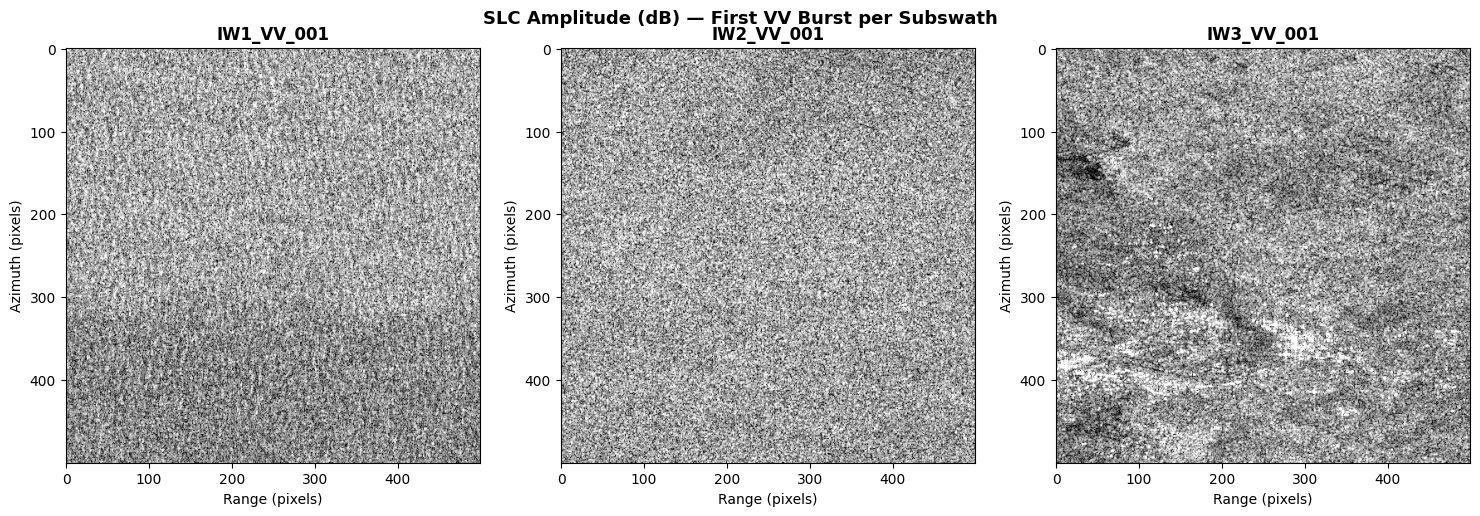

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (sw, ds) in enumerate(burst_datasets.items()):
    # Read a 500x500 centre crop
    xoff = (ds.RasterXSize - 500) // 2
    yoff = (ds.RasterYSize - 500) // 2
    data = ds.GetRasterBand(1).ReadAsArray(xoff, yoff, 500, 500)

    amp_db = 10 * np.log10(np.abs(data) + 1)
    vmin, vmax = np.nanpercentile(amp_db, [2, 98])

    axes[idx].imshow(amp_db, cmap='gray', vmin=vmin, vmax=vmax)
    axes[idx].set_title(f"{sw}_VV_001", fontweight='bold')
    axes[idx].set_xlabel("Range (pixels)")
    axes[idx].set_ylabel("Azimuth (pixels)")

plt.suptitle("SLC Amplitude (dB) — First VV Burst per Subswath", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

(ComparePolarizations)=
## Compare Polarizations

VV (co-polarization) and VH (cross-polarization) capture different scattering characteristics from the same scene.

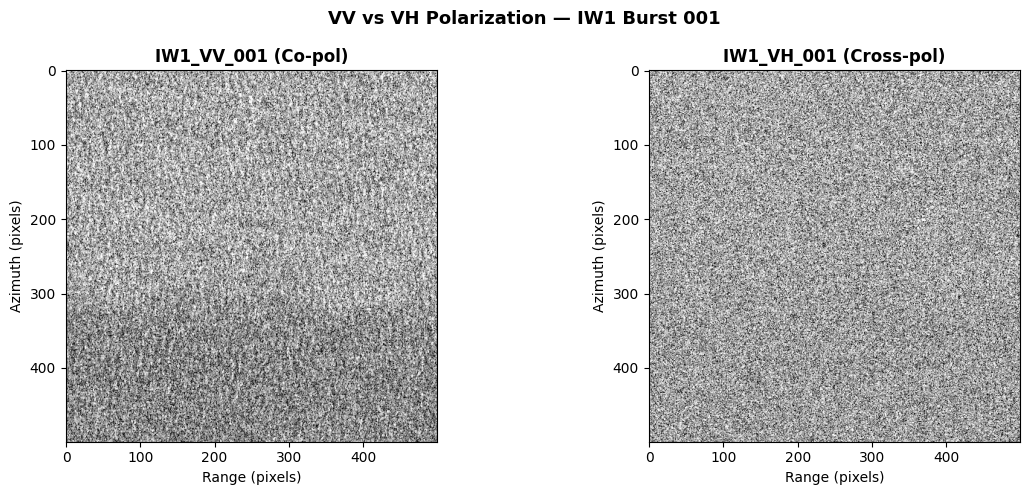

In [7]:
ds_vv = gdal.OpenEx(f"EOPFZARR:'{SLC_URL}'", gdal.OF_RASTER, open_options=["BURST=IW1_VV_001"])
ds_vh = gdal.OpenEx(f"EOPFZARR:'{SLC_URL}'", gdal.OF_RASTER, open_options=["BURST=IW1_VH_001"])

xoff = (ds_vv.RasterXSize - 500) // 2
yoff = (ds_vv.RasterYSize - 500) // 2

vv_amp = 10 * np.log10(np.abs(ds_vv.GetRasterBand(1).ReadAsArray(xoff, yoff, 500, 500)) + 1)
vh_amp = 10 * np.log10(np.abs(ds_vh.GetRasterBand(1).ReadAsArray(xoff, yoff, 500, 500)) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes, [vv_amp, vh_amp], ["IW1_VV_001 (Co-pol)", "IW1_VH_001 (Cross-pol)"]):
    vmin, vmax = np.nanpercentile(data, [2, 98])
    ax.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Range (pixels)")
    ax.set_ylabel("Azimuth (pixels)")

plt.suptitle("VV vs VH Polarization — IW1 Burst 001", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ds_vv = ds_vh = None

(Summary)=
## Summary

The `BURST` open option in the EOPFZARR driver provides direct access to individual Sentinel-1 SLC bursts by friendly name, without navigating hundreds of subdatasets.

| Feature | Description |
|---------|-------------|
| **Naming scheme** | `{subswath}_{polarization}_{index}` e.g. `IW1_VV_001` |
| **Case insensitive** | `iw1_vv_001` and `IW1_VV_001` are equivalent |
| **Data type** | CFloat32 (complex single-precision) |
| **Metadata** | Burst name, subswath, polarization, and index exposed via GDAL metadata |

```python
# Open a specific burst
ds = gdal.OpenEx(
    "EOPFZARR:'/vsicurl/...SLC...zarr'",
    open_options=["BURST=IW1_VV_001"]
)
amplitude = np.abs(ds.GetRasterBand(1).ReadAsArray())
```

```bash
# Command line
gdalinfo "EOPFZARR:'/vsicurl/...SLC...zarr'" -oo BURST=IW1_VV_001
```

In [8]:
# Cleanup
for ds in burst_datasets.values():
    ds = None
burst_datasets.clear()
if 'ds_burst' in dir():
    ds_burst = None
print("Done.")

Done.


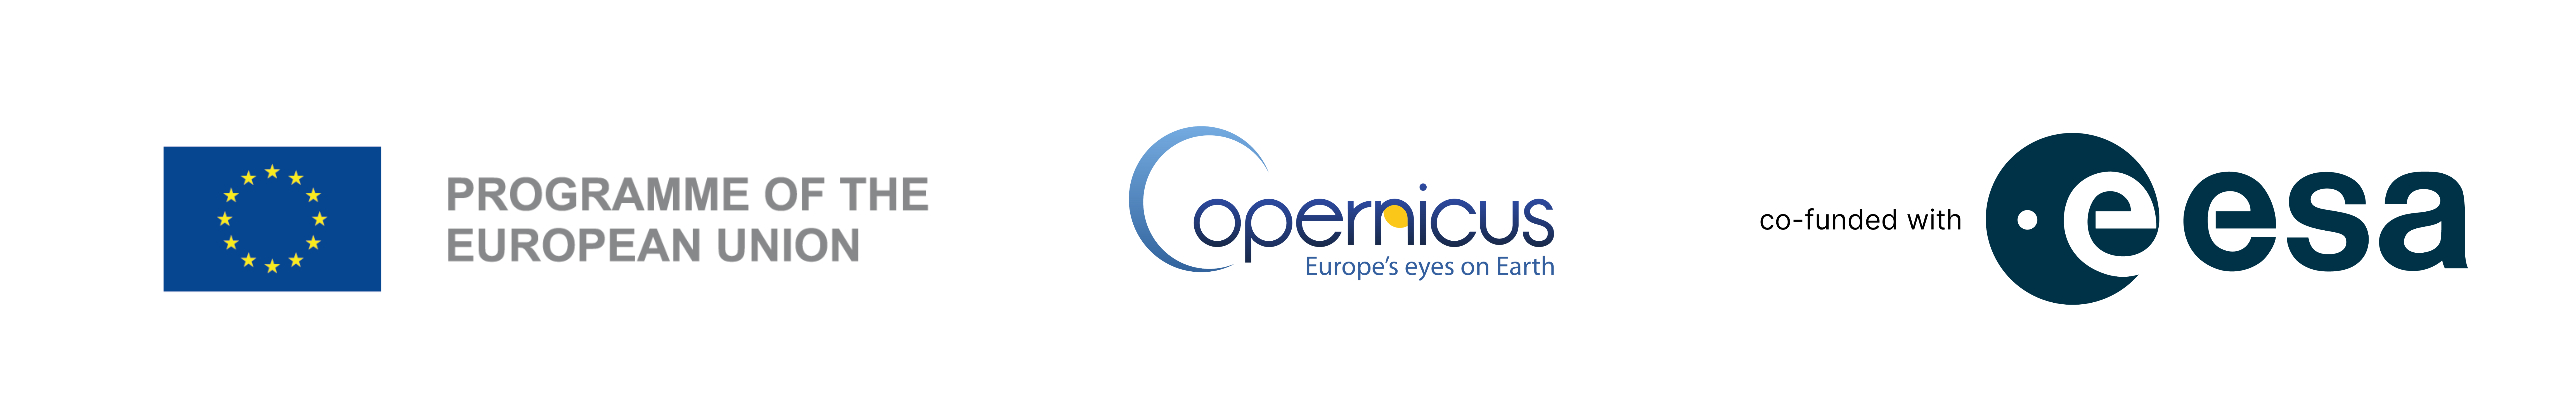